<center>
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
            padding: 12px 40px;
            border-radius: 8px;
            border-left: 4px solid #00d4ff;
            box-shadow: 0 4px 20px rgba(0, 212, 255, 0.15);
            margin: 15px 0;
            width: 100%;
            box-sizing: border-box;">
    <h1 style="color: #00d4ff; 
               font-family: 'Consolas', 'Courier New', monospace; 
               font-size: 28px; 
               font-weight: 700; 
               margin: 0;
               letter-spacing: 1px;
               text-shadow: 0 0 20px rgba(0, 212, 255, 0.3);
               text-align: center;">
        🎯 DATA_GENERATION
    </h1>
    <p style="color: rgba(255,255,255,0.6); 
              font-size: 13px; 
              margin: 4px 0 0 0;
              font-family: 'Consolas', 'Courier New', monospace;
              letter-spacing: 0.5px;
              text-align: center;">
        synthetic_data · visualization · geometry
    </p>
</div>
</center>

## 📐 1. Многомерное нормальное распределение

### Что это и зачем нам?

Для генерации синтетических данных для SVM нам нужно создавать **облака точек** — классы, которые мы будем разделять. Самое естественное и контролируемое распределение для этого — **многомерное нормальное (гауссовское)** распределение.

Обычное (одномерное) нормальное распределение задаётся двумя числами: средним $\mu$ и дисперсией $\sigma^2$.

В двумерном случае (наш график, две оси) распределение задаётся:

- **вектором среднего** $\mu = (\mu_x, \mu_y)$ — это координаты центра облака точек
- **ковариационной матрицей** $\Sigma$ — это то, что определяет **форму** облака (круг, овал, наклон)

$$\Sigma = \begin{pmatrix}\sigma_x^2 & \sigma_{xy}\\ \sigma_{xy} & \sigma_y^2\end{pmatrix}$$

**Метод numpy.random.multivariate_normal**:
https://numpy.org/doc/2.1/reference/random/generated/numpy.random.multivariate_normal.html

### Как эта матрица управляет формой облака

- **$\sigma_x^2$** — разброс вдоль оси X (дисперсия по x). Чем больше — тем шире облако **по горизонтали**.
- **$\sigma_y^2$** — разброс вдоль оси Y. Чем больше — тем выше облако **по вертикали**.
- **$\sigma_{xy}$** (недиагональный элемент, ковариация) — это то, что **наклоняет** овал. Если он равен нулю, оси овала параллельны осям координат (никакого наклона). Если он ненулевой — облако превращается в **наклонённый эллипс** (точки с большим x чаще имеют и большой y, если ковариация положительная).

### Практическое правило для формы

| Что хочешь получить | Как задать $\Sigma$ |
|---|---|
| Круг | $\sigma_x^2 = \sigma_y^2$, $\sigma_{xy} = 0$ |
| Овал вытянут по горизонтали | $\sigma_x^2 > \sigma_y^2$, $\sigma_{xy} = 0$ |
| Овал вытянут по вертикали | $\sigma_y^2 > \sigma_x^2$, $\sigma_{xy} = 0$ |
| Наклонённый овал | $\sigma_{xy} \neq 0$ (чем ближе к $\sqrt{\sigma_x^2 \sigma_y^2}$, тем сильнее "сплющен" по диагонали) |

### Как это генерируется — на уровне идеи (без кода)

Функция для генерации из многомерного нормального распределения принимает три вещи: вектор среднего (куда "поставить" центр облака — фактически задаёт положение целого класса на плоскости), ковариационную матрицу (форму и наклон), и количество точек. На выходе — массив формы `(n, 2)` — то есть `n` строк (объектов), 2 столбца (координаты x, y). Это уже готовый numpy-массив в правильном формате для одного класса.

### Как сделать два класса

Генерируешь **два независимых облака** с разными координатами (чтобы они не совпадали в пространстве — иначе не будет никакой разделимости вообще) и, возможно, разной формой ковариации (можно сделать один класс кругом, другой — овалом, для разнообразия). Потом эти два массива **склеиваешь по строкам** (`np.vstack` или `np.concatenate` по оси 0) — получаешь единый массив `X`, и отдельно создаёшь вектор меток `y` той же длины (например, первые `n1` меток = `-1`, следующие `n2` = `+1`).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Создание массивов и их объединение

# координаты среднего
coordinate_vector_1 = np.array([-2, 0])

# ковариационная матрица
sigma_1 = np.array([[0.5, 0.0],
                    [0.0, 0.5]])

# Создание облака точек
X_1 = np.random.multivariate_normal(coordinate_vector_1, sigma_1, 5)
y_1 = -np.ones(5)


# второй массив
coordinate_vector_2 = np.array([2, 0])

sigma_2 = np.array([[0.5, 0.0],
                    [0.0, 0.5]])

X_2 = np.random.multivariate_normal(coordinate_vector_2, sigma_2, 5)
y_2 = np.ones(5)

# Теперь у нас имеется X_1 и X_2, они имеют по пять координат по Ox и Oy
# Теперь их надо объединить, порядок важен

# Склеиваются они по порядку
X = np.concatenate([X_1, X_2], axis=0) # по вертикали
y = np.concatenate([y_1, y_2], axis=0) # по горизонтали - то есть склеиваем два ряда в один

# вот они
for i in range(len(X)):
    print(f"Точка {i}: X = ({X[i, 0]:.2f}, {X[i, 1]:.2f}), класс = {int(y[i])}")

Точка 0: X = (-1.46, 0.19), класс = -1
Точка 1: X = (-2.36, -0.66), класс = -1
Точка 2: X = (-0.49, -0.16), класс = -1
Точка 3: X = (-2.24, -0.48), класс = -1
Точка 4: X = (-3.05, -0.05), класс = -1
Точка 5: X = (1.57, 1.73), класс = 1
Точка 6: X = (2.48, 0.92), класс = 1
Точка 7: X = (3.03, 0.60), класс = 1
Точка 8: X = (3.18, 0.30), класс = 1
Точка 9: X = (2.90, -0.96), класс = 1


<pre>
X — склеиваем по вертикали (vstack / axis=0)

X_1:            X_2:            Результат:
[1.0, 2.0]      [7.0, 8.0]      [1.0, 2.0]
[3.0, 4.0]      [9.0, 10.0]     [3.0, 4.0]
[5.0, 6.0]       ...            [5.0, 6.0]
                                 [7.0, 8.0]
                                 [9.0, 10.0]
                                 ...
Увеличивается число строк: (5,2) + (5,2) → (10,2)

y — склеиваем по горизонтали (hstack)

y_1:      y_2:      Результат:
[0]       [1]       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
[0]       [1]
[0]       [1]
[0]       [1]
[0]       [1]
Увеличивается длина вектора: (5,) + (5,) → (10,)
</pre>

In [6]:
n_samples = 100000  # количество точек

# Класс -1: центр в (-3, 0), круглая форма

mu_1 = np.array([-5, 0])
sigma_1 = np.array([[1.0, 0.0],
                    [0.0, 1.0]])
X_1 = np.random.multivariate_normal(mu_1, sigma_1, n_samples)
y_1 = -np.ones(n_samples)  # метки класса -1


# Класс +1: центр в (3, 0), овал по вертикали и еще под углом (влияение "3")
mu_2 = np.array([5, 0])
sigma_2 = np.array([[1.0, 0.0],
                    [3.0, 4.0]])
X_2 = np.random.multivariate_normal(mu_2, sigma_2, n_samples)
y_2 = np.ones(n_samples)   # метки класса +1

# Склеиваем данные в один массив
X = np.vstack([X_1, X_2])      # объединяем по строкам
y = np.hstack([y_1, y_2])      # объединяем метки

print(f"X shape: {X.shape}")   # (400, 2) — 400 точек, 2 признака
print(f"y shape: {y.shape}")   # (400,) — 400 меток

X shape: (200000, 2)
y shape: (200000,)


C:\Users\ZiganshinShamil\AppData\Local\Temp\ipykernel_12384\3899326863.py:16: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_2 = np.random.multivariate_normal(mu_2, sigma_2, n_samples)


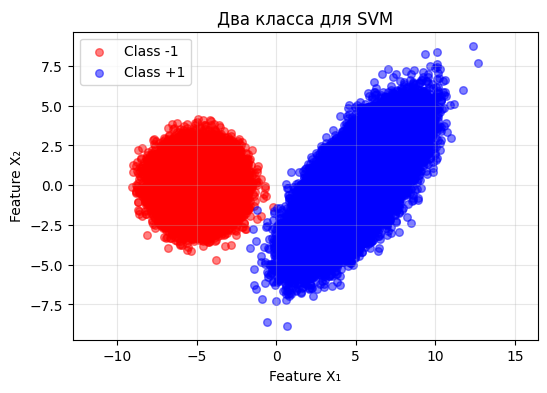

In [7]:
# Создаёт новый график (фигуру) размером 5×3 дюймов
plt.figure(figsize=(6, 4))

# Рисует красные точки для всех объектов, у которых метка -1
# y == -1 — создаёт массив [True, False, True, ...] (маска)
plt.scatter(X[y == -1, 0], X[y == -1, 1],
            color='red', label='Class -1', s=30, alpha=0.5)

# Точки класса +1 (синие) - берёт из X только те строки, где True, и только первый столбец (координата X)
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color='blue', label='Class +1', s=30, alpha=0.5)

# s=30	30	Размер точки (чем больше число, тем крупнее)
# alpha=0.7	0.7	Прозрачность (0 — невидимо, 1 — полностью видимо)

plt.xlabel('Feature X₁')
plt.ylabel('Feature X₂')
plt.title('Два класса для SVM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## Создание тестового датасета

### Цель эксперимента
Сгенерировать нелинейно разделимый датасет для проверки эффективности 
разработанного пользовательского ядра.

### Выбор датасета
Используется `make_circles()` по следующим причинам:
- Классический пример нелинейной разделимости
- Позволяет наглядно оценить качество ядра
- Простая интерпретация результатов

### Параметры генерации
- `n_samples=300`: 150 точек на класс
- `factor=0.5`: внутренний круг вдвое меньше внешнего
- `noise=0.05`: добавлен шум для приближения к реальным данным

### Преобразование меток
Метки приводятся к формату {-1, 1} для совместимости с SVM:
- Внутренний круг → -1
- Внешний круг → +1

In [ ]:

from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(
    n_samples=300,
    factor=0.5,      # отношение радиусов: R_inside / R_outside = 0.5
    noise=0.05,      # небольшой шум
    random_state=42
)

print(X_circles.shape, y_circles.shape)

(300, 2) (300,)


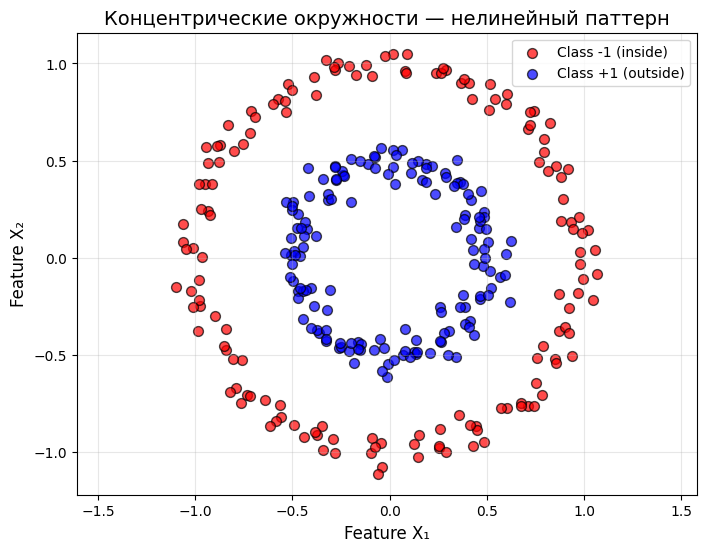

In [ ]:


# ============================================
# Генерация концентрических окружностей
# ============================================

from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(
    n_samples=300,
    factor=0.5,      # отношение радиусов: R_inside / R_outside = 0.5
    noise=0.05,      # небольшой шум
    random_state=42
)

# np.where(условие, значение_если_True, значение_если_False)
y_circles = np.where(y_circles == 0, -1, 1)  # -1 внутри, +1 снаружи

# Визуализация
plt.figure(figsize=(8, 6))

plt.scatter(
    X_circles[y_circles == -1, 0],
    X_circles[y_circles == -1, 1],
    color='red', label='Class -1 (inside)', s=50, alpha=0.7, edgecolors='k'
)
plt.scatter(
    X_circles[y_circles == 1, 0],
    X_circles[y_circles == 1, 1],
    color='blue', label='Class +1 (outside)', s=50, alpha=0.7, edgecolors='k'
)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Концентрические окружности — нелинейный паттерн', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

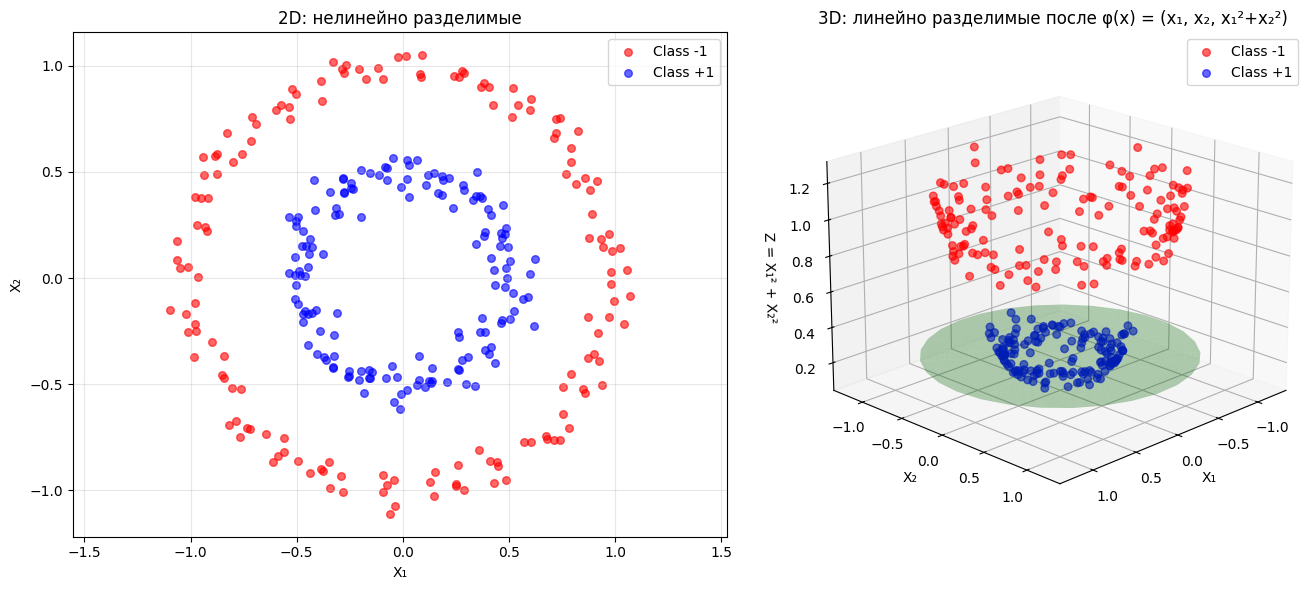

In [9]:
# ============================================
# Преобразование в 3D: φ(x) = (x₁, x₂, x₁² + x₂²)
# ============================================

from mpl_toolkits.mplot3d import Axes3D

# Добавляем третью координату: квадрат расстояния от центра
X_circles_3d = np.column_stack([
    X_circles[:, 0],                        # x₁
    X_circles[:, 1],                        # x₂
    X_circles[:, 0]**2 + X_circles[:, 1]**2 # z = x₁² + x₂²
])

# ============================================
# Визуализация в 3D
# ============================================

fig = plt.figure(figsize=(14, 6))

# --- 2D проекция (вид сверху) ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(
    X_circles[y_circles == -1, 0],
    X_circles[y_circles == -1, 1],
    color='red', label='Class -1', s=30, alpha=0.6
)
ax1.scatter(
    X_circles[y_circles == 1, 0],
    X_circles[y_circles == 1, 1],
    color='blue', label='Class +1', s=30, alpha=0.6
)
ax1.set_title('2D: нелинейно разделимые', fontsize=12)
ax1.set_xlabel('X₁')
ax1.set_ylabel('X₂')
ax1.legend()
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# --- 3D проекция (вид сбоку) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(
    X_circles_3d[y_circles == -1, 0],
    X_circles_3d[y_circles == -1, 1],
    X_circles_3d[y_circles == -1, 2],
    color='red', label='Class -1', s=30, alpha=0.6
)
ax2.scatter(
    X_circles_3d[y_circles == 1, 0],
    X_circles_3d[y_circles == 1, 1],
    X_circles_3d[y_circles == 1, 2],
    color='blue', label='Class +1', s=30, alpha=0.6
)

# Рисуем разделяющую плоскость в 3D (z = R²)
R = 0.5  # граница между классами
theta_plane = np.linspace(0, 2*np.pi, 30)
r_plane = np.linspace(0, 1.2, 30)
R_grid, Theta_grid = np.meshgrid(r_plane, theta_plane)
X_plane = R_grid * np.cos(Theta_grid)
Y_plane = R_grid * np.sin(Theta_grid)
Z_plane = R**2 * np.ones_like(X_plane)  # горизонтальная плоскость

ax2.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.3, color='green', edgecolor='none')
ax2.set_title('3D: линейно разделимые после φ(x) = (x₁, x₂, x₁²+x₂²)', fontsize=12)
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Z = X₁² + X₂²')
ax2.view_init(elev=20, azim=45)
ax2.legend()

plt.tight_layout()
plt.show()

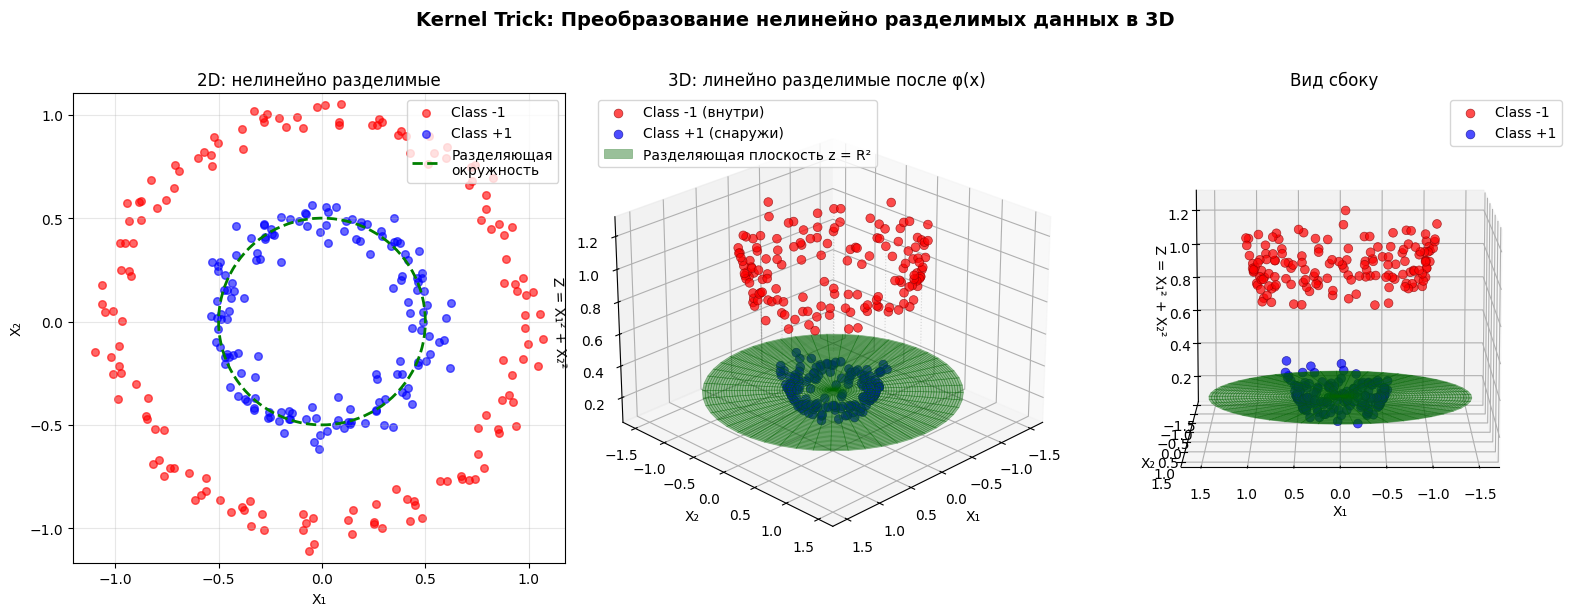

In [10]:
# ============================================
# Преобразование в 3D: φ(x) = (x₁, x₂, x₁² + x₂²)
# ============================================

from mpl_toolkits.mplot3d import Axes3D

# Добавляем третью координату: квадрат расстояния от центра
X_circles_3d = np.column_stack([
    X_circles[:, 0],                        # x₁
    X_circles[:, 1],                        # x₂
    X_circles[:, 0]**2 + X_circles[:, 1]**2 # z = x₁² + x₂²
])

# ============================================
# УЛУЧШЕННАЯ ВИЗУАЛИЗАЦИЯ В 3D
# ============================================

fig = plt.figure(figsize=(16, 6))

# --- 2D проекция (вид сверху) ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(
    X_circles[y_circles == -1, 0],
    X_circles[y_circles == -1, 1],
    color='red', label='Class -1', s=30, alpha=0.6
)
ax1.scatter(
    X_circles[y_circles == 1, 0],
    X_circles[y_circles == 1, 1],
    color='blue', label='Class +1', s=30, alpha=0.6
)
# Рисуем разделяющую окружность в 2D
theta = np.linspace(0, 2*np.pi, 100)
R = 0.5
ax1.plot(R*np.cos(theta), R*np.sin(theta), 'g--', linewidth=2, label='Разделяющая\nокружность')
ax1.set_title('2D: нелинейно разделимые', fontsize=12)
ax1.set_xlabel('X₁')
ax1.set_ylabel('X₂')
ax1.legend(loc='upper right')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# --- 3D проекция (улучшенный вид) ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

# Внутренние точки (класс -1) - ниже плоскости
scatter_inner = ax2.scatter(
    X_circles_3d[y_circles == -1, 0],
    X_circles_3d[y_circles == -1, 1],
    X_circles_3d[y_circles == -1, 2],
    color='red', label='Class -1 (внутри)', s=40, alpha=0.7,
    edgecolors='darkred', linewidth=0.5
)

# Внешние точки (класс +1) - выше плоскости
scatter_outer = ax2.scatter(
    X_circles_3d[y_circles == 1, 0],
    X_circles_3d[y_circles == 1, 1],
    X_circles_3d[y_circles == 1, 2],
    color='blue', label='Class +1 (снаружи)', s=40, alpha=0.7,
    edgecolors='darkblue', linewidth=0.5
)

# Рисуем разделяющую плоскость в 3D (z = R²)
R = 0.5
# Создаем более детальную сетку для плоскости
theta_plane = np.linspace(0, 2*np.pi, 50)
r_plane = np.linspace(0, 1.5, 50)
R_grid, Theta_grid = np.meshgrid(r_plane, theta_plane)
X_plane = R_grid * np.cos(Theta_grid)
Y_plane = R_grid * np.sin(Theta_grid)
Z_plane = R**2 * np.ones_like(X_plane)

# Полупрозрачная плоскость с сеткой
surface = ax2.plot_surface(
    X_plane, Y_plane, Z_plane, 
    alpha=0.4, color='green', edgecolor='darkgreen', 
    linewidth=0.5, label='Разделяющая плоскость z = R²'
)

# Добавляем линии для наглядности
# Вертикальные линии от некоторых точек до плоскости
for i in range(0, len(X_circles_3d), 20):  # Каждую 20-ю точку
    ax2.plot(
        [X_circles_3d[i, 0], X_circles_3d[i, 0]],
        [X_circles_3d[i, 1], X_circles_3d[i, 1]],
        [R**2, X_circles_3d[i, 2]],
        'gray', alpha=0.3, linewidth=0.8, linestyle=':'
    )

ax2.set_title('3D: линейно разделимые после φ(x)', fontsize=12)
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Z = X₁² + X₂²')
ax2.view_init(elev=25, azim=45)
ax2.legend(loc='upper left')

# --- 3D вид с другого ракурса ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

ax3.scatter(
    X_circles_3d[y_circles == -1, 0],
    X_circles_3d[y_circles == -1, 1],
    X_circles_3d[y_circles == -1, 2],
    color='red', s=40, alpha=0.7, edgecolors='darkred', linewidth=0.5
)

ax3.scatter(
    X_circles_3d[y_circles == 1, 0],
    X_circles_3d[y_circles == 1, 1],
    X_circles_3d[y_circles == 1, 2],
    color='blue', s=40, alpha=0.7, edgecolors='darkblue', linewidth=0.5
)

ax3.plot_surface(
    X_plane, Y_plane, Z_plane, 
    alpha=0.4, color='green', edgecolor='darkgreen', linewidth=0.5
)

ax3.set_title('Вид сбоку', fontsize=12)
ax3.set_xlabel('X₁')
ax3.set_ylabel('X₂')
ax3.set_zlabel('Z = X₁² + X₂²')
ax3.view_init(elev=10, azim=90)  # Вид сбоку для лучшего восприятия разделения
ax3.legend(['Class -1', 'Class +1'])

plt.suptitle('Kernel Trick: Преобразование нелинейно разделимых данных в 3D', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

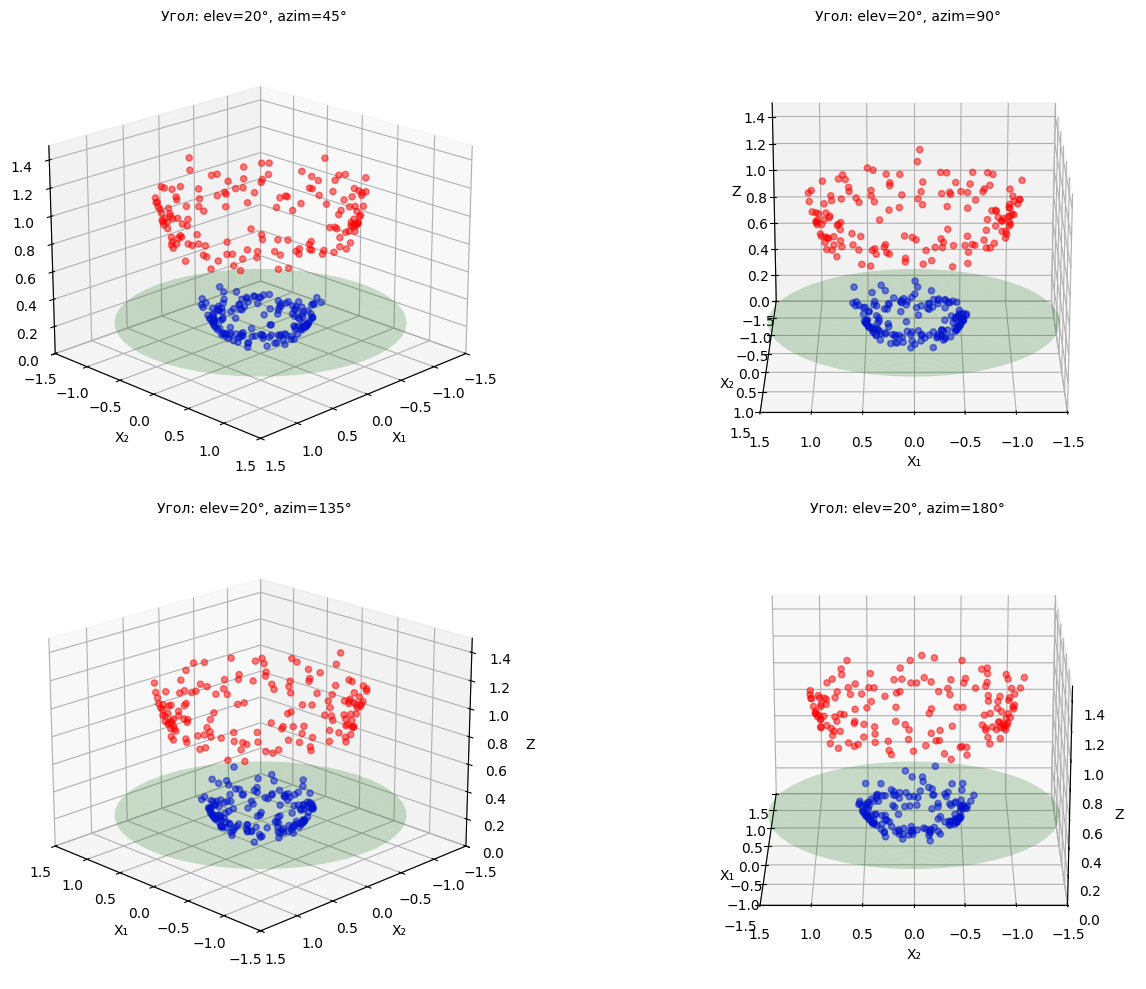

In [11]:
# ============================================
# 3D с разных углов (интерактивный просмотр)
# ============================================

# Для интерактивного вращения используем %matplotlib notebook
# В Jupyter: %matplotlib notebook
# В обычном режиме показываем статичные углы

fig = plt.figure(figsize=(15, 10))

angles = [(20, 45), (20, 90), (20, 135), (20, 180)]

for i, (elev, azim) in enumerate(angles, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    ax.scatter(
        X_circles_3d[y_circles == -1, 0],
        X_circles_3d[y_circles == -1, 1],
        X_circles_3d[y_circles == -1, 2],
        color='red', label='-1', s=20, alpha=0.5
    )
    ax.scatter(
        X_circles_3d[y_circles == 1, 0],
        X_circles_3d[y_circles == 1, 1],
        X_circles_3d[y_circles == 1, 2],
        color='blue', label='+1', s=20, alpha=0.5
    )
    
    # Плоскость z = R²
    R = 0.5
    X_plane = R_grid * np.cos(Theta_grid)
    Y_plane = R_grid * np.sin(Theta_grid)
    Z_plane = R**2 * np.ones_like(X_plane)
    ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.2, color='green', edgecolor='none')
    
    ax.set_title(f'Угол: elev={elev}°, azim={azim}°', fontsize=10)
    ax.set_xlabel('X₁')
    ax.set_ylabel('X₂')
    ax.set_zlabel('Z')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_zlim([0, 1.5])

plt.tight_layout()
plt.show()

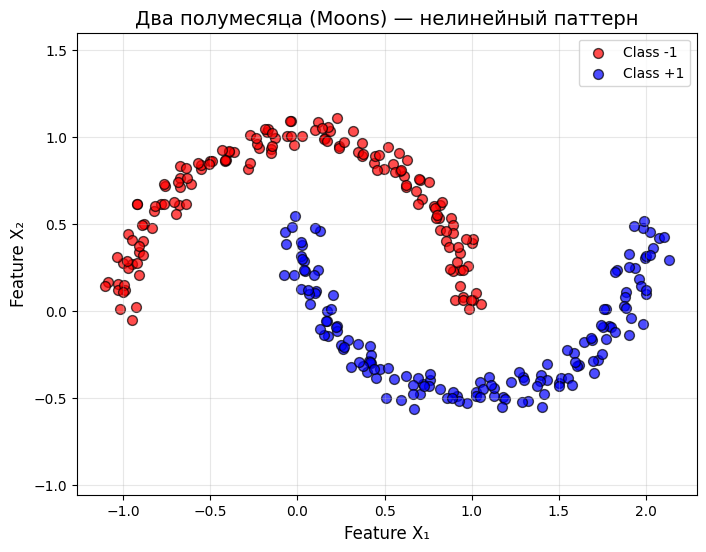

In [12]:
# ============================================
# Генерация двух полумесяцев
# ============================================

from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)
y_moons = np.where(y_moons == 0, -1, 1)

# Визуализация
plt.figure(figsize=(8, 6))

plt.scatter(
    X_moons[y_moons == -1, 0],
    X_moons[y_moons == -1, 1],
    color='red', label='Class -1', s=50, alpha=0.7, edgecolors='k'
)
plt.scatter(
    X_moons[y_moons == 1, 0],
    X_moons[y_moons == 1, 1],
    color='blue', label='Class +1', s=50, alpha=0.7, edgecolors='k'
)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Два полумесяца (Moons) — нелинейный паттерн', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

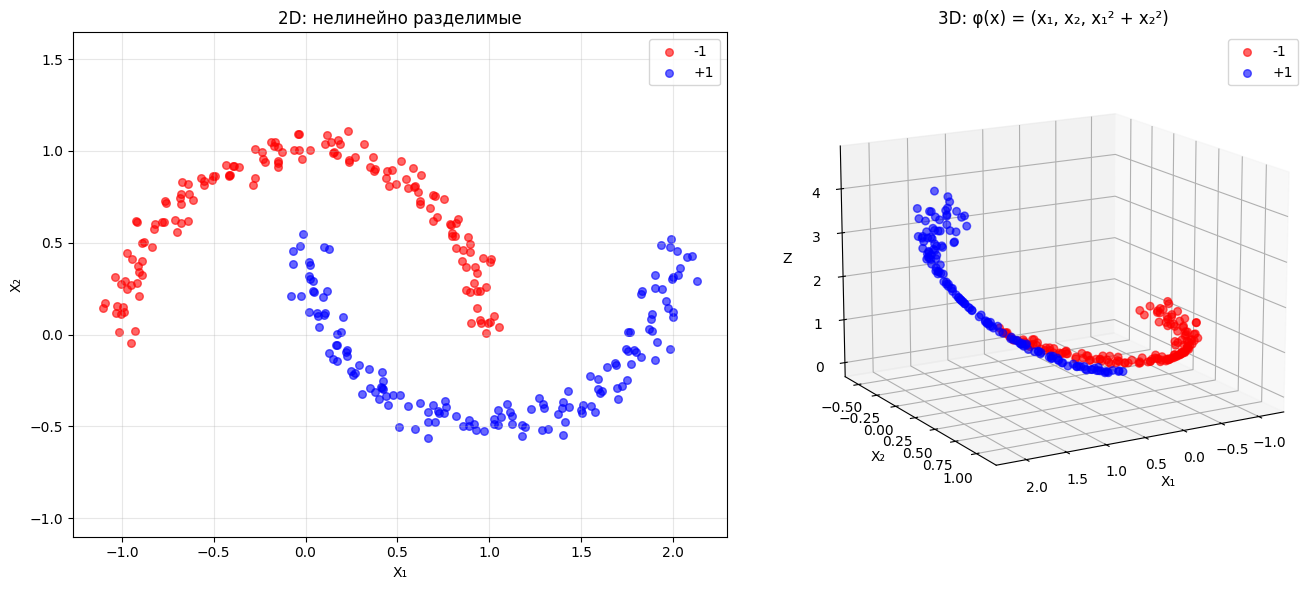

In [13]:
# ============================================
# Преобразование Moons в 3D: φ(x) = (x₁, x₂, x₁² + x₂²)
# ============================================

X_moons_3d = np.column_stack([
    X_moons[:, 0],
    X_moons[:, 1],
    X_moons[:, 0]**2 + X_moons[:, 1]**2
])

# ============================================
# Визуализация Moons в 3D
# ============================================

fig = plt.figure(figsize=(14, 6))

# 2D
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(
    X_moons[y_moons == -1, 0],
    X_moons[y_moons == -1, 1],
    color='red', label='-1', s=30, alpha=0.6
)
ax1.scatter(
    X_moons[y_moons == 1, 0],
    X_moons[y_moons == 1, 1],
    color='blue', label='+1', s=30, alpha=0.6
)
ax1.set_title('2D: нелинейно разделимые', fontsize=12)
ax1.set_xlabel('X₁')
ax1.set_ylabel('X₂')
ax1.legend()
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(
    X_moons_3d[y_moons == -1, 0],
    X_moons_3d[y_moons == -1, 1],
    X_moons_3d[y_moons == -1, 2],
    color='red', label='-1', s=30, alpha=0.6
)
ax2.scatter(
    X_moons_3d[y_moons == 1, 0],
    X_moons_3d[y_moons == 1, 1],
    X_moons_3d[y_moons == 1, 2],
    color='blue', label='+1', s=30, alpha=0.6
)
ax2.set_title('3D: φ(x) = (x₁, x₂, x₁² + x₂²)', fontsize=12)
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Z')
ax2.view_init(elev=15, azim=60)
ax2.legend()

plt.tight_layout()
plt.show()

Точность SVM в 3D: 88.33%
Уравнение плоскости: 0.76x₁ + -2.98x₂ + 0.03z + 0.29 = 0


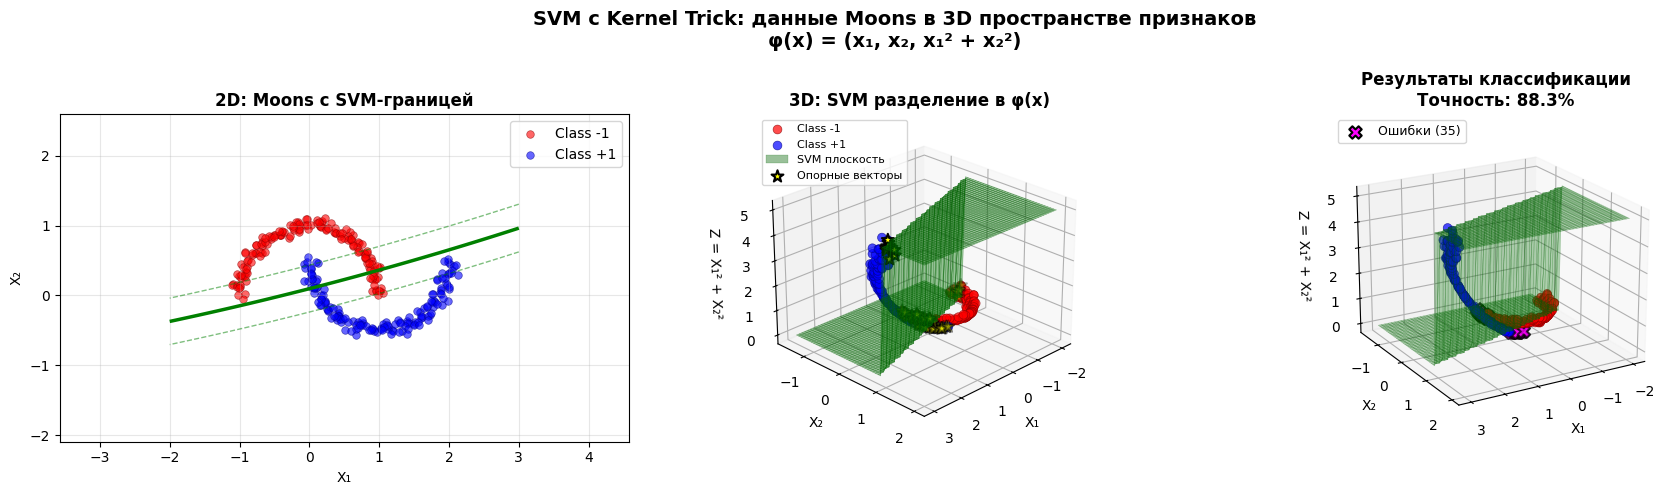

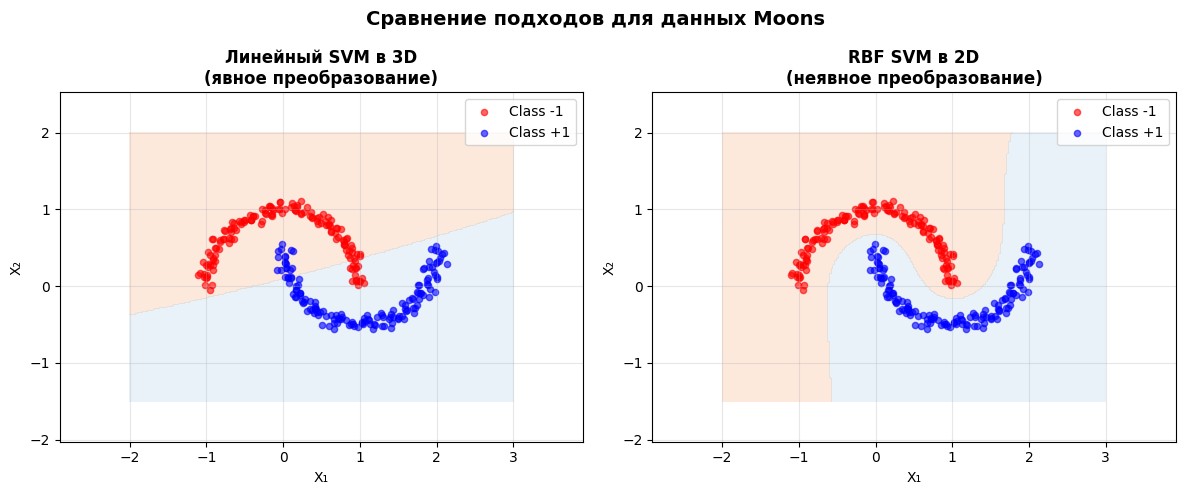


АНАЛИЗ РАЗДЕЛЕНИЯ MOONS:
Линейный SVM в 3D (явное φ): точность = 88.33%
RBF SVM в 2D (kernel trick): точность = 100.00%
Количество опорных векторов (3D): 90
Количество опорных векторов (RBF): 38

Важно: простое преобразование x₁² + x₂² недостаточно
для идеального разделения moons. Нужно более сложное
преобразование (как в RBF kernel).


In [14]:
# ============================================
# Преобразование Moons в 3D и разделение SVM
# ============================================

from sklearn import svm

X_moons_3d = np.column_stack([
    X_moons[:, 0],
    X_moons[:, 1],
    X_moons[:, 0]**2 + X_moons[:, 1]**2
])

# Обучаем линейный SVM в 3D пространстве
svm_moons_3d = svm.SVC(kernel='linear', C=1.0)
svm_moons_3d.fit(X_moons_3d, y_moons)

# Параметры разделяющей плоскости
w = svm_moons_3d.coef_[0]
b = svm_moons_3d.intercept_[0]

# Точность на обучающей выборке
accuracy = svm_moons_3d.score(X_moons_3d, y_moons)
print(f"Точность SVM в 3D: {accuracy:.2%}")
print(f"Уравнение плоскости: {w[0]:.2f}x₁ + {w[1]:.2f}x₂ + {w[2]:.2f}z + {b:.2f} = 0")

# ============================================
# Визуализация Moons в 3D с SVM-плоскостью
# ============================================

fig = plt.figure(figsize=(18, 5))

# --- 2D с проекцией разделяющей кривой ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(
    X_moons[y_moons == -1, 0],
    X_moons[y_moons == -1, 1],
    color='red', label='Class -1', s=30, alpha=0.6, edgecolors='darkred', linewidth=0.5
)
ax1.scatter(
    X_moons[y_moons == 1, 0],
    X_moons[y_moons == 1, 1],
    color='blue', label='Class +1', s=30, alpha=0.6, edgecolors='darkblue', linewidth=0.5
)

# Разделяющая кривая в 2D: w[0]x + w[1]y + w[2](x²+y²) + b = 0
# Это окружность: x² + y² + (w[0]/w[2])x + (w[1]/w[2])y + b/w[2] = 0
xx_2d, yy_2d = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
zz_2d = w[0]*xx_2d + w[1]*yy_2d + w[2]*(xx_2d**2 + yy_2d**2) + b
ax1.contour(xx_2d, yy_2d, zz_2d, levels=[0], colors='green', linewidths=2.5, linestyles='-')
ax1.contour(xx_2d, yy_2d, zz_2d, levels=[-1, 1], colors='green', linewidths=1, linestyles='--', alpha=0.5)

ax1.set_title('2D: Moons с SVM-границей', fontsize=12, fontweight='bold')
ax1.set_xlabel('X₁')
ax1.set_ylabel('X₂')
ax1.legend()
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# --- 3D с SVM-плоскостью ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

# Все точки
ax2.scatter(
    X_moons_3d[y_moons == -1, 0],
    X_moons_3d[y_moons == -1, 1],
    X_moons_3d[y_moons == -1, 2],
    color='red', s=40, alpha=0.7, edgecolors='darkred', linewidth=0.5, label='Class -1'
)
ax2.scatter(
    X_moons_3d[y_moons == 1, 0],
    X_moons_3d[y_moons == 1, 1],
    X_moons_3d[y_moons == 1, 2],
    color='blue', s=40, alpha=0.7, edgecolors='darkblue', linewidth=0.5, label='Class +1'
)

# Сетка для SVM-плоскости
xx, yy = np.meshgrid(np.linspace(-2, 3, 50), np.linspace(-1.5, 2, 50))
zz = (-w[0] * xx - w[1] * yy - b) / w[2]

# Ограничиваем z для лучшей визуализации
zz = np.clip(zz, 0, 5)

# SVM разделяющая плоскость
ax2.plot_surface(xx, yy, zz, alpha=0.4, color='green', 
                 edgecolor='darkgreen', linewidth=0.3, label='SVM плоскость')

# Опорные векторы
support_vectors = svm_moons_3d.support_vectors_
ax2.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    support_vectors[:, 2],
    color='yellow', s=80, marker='*', edgecolors='black', 
    linewidth=1.5, label='Опорные векторы', zorder=5
)

ax2.set_title('3D: SVM разделение в φ(x)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Z = X₁² + X₂²')
ax2.view_init(elev=25, azim=45)
ax2.legend(loc='upper left', fontsize=8)

# --- 3D вид, показывающий неидеальность разделения ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Раскрашиваем точки по предсказанию SVM
y_pred = svm_moons_3d.predict(X_moons_3d)
correct = y_pred == y_moons

# Правильно классифицированные
ax3.scatter(
    X_moons_3d[correct & (y_moons == -1), 0],
    X_moons_3d[correct & (y_moons == -1), 1],
    X_moons_3d[correct & (y_moons == -1), 2],
    color='red', s=40, alpha=0.7, edgecolors='darkred', linewidth=0.5
)
ax3.scatter(
    X_moons_3d[correct & (y_moons == 1), 0],
    X_moons_3d[correct & (y_moons == 1), 1],
    X_moons_3d[correct & (y_moons == 1), 2],
    color='blue', s=40, alpha=0.7, edgecolors='darkblue', linewidth=0.5
)

# Ошибки классификации
ax3.scatter(
    X_moons_3d[~correct, 0],
    X_moons_3d[~correct, 1],
    X_moons_3d[~correct, 2],
    color='magenta', s=80, marker='X', edgecolors='black', 
    linewidth=1.5, label=f'Ошибки ({sum(~correct)})', zorder=5
)

# Плоскость
ax3.plot_surface(xx, yy, zz, alpha=0.3, color='green', 
                 edgecolor='darkgreen', linewidth=0.3)

ax3.set_title(f'Результаты классификации\nТочность: {accuracy:.1%}', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('X₁')
ax3.set_ylabel('X₂')
ax3.set_zlabel('Z = X₁² + X₂²')
ax3.view_init(elev=20, azim=60)
ax3.legend(loc='upper left', fontsize=9)

plt.suptitle('SVM с Kernel Trick: данные Moons в 3D пространстве признаков\n'
             'φ(x) = (x₁, x₂, x₁² + x₂²)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Сравнение с RBF SVM в исходном 2D пространстве
# ============================================

fig2, axes = plt.subplots(1, 2, figsize=(12, 5))

# RBF SVM в 2D
svm_rbf = svm.SVC(kernel='rbf', gamma=1, C=1.0)
svm_rbf.fit(X_moons, y_moons)

# Визуализация RBF SVM
for ax, title in zip(axes, ['Линейный SVM в 3D\n(явное преобразование)', 
                               'RBF SVM в 2D\n(неявное преобразование)']):
    xx_plot, yy_plot = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
    
    if '3D' in title:
        # Предсказание через 3D преобразование
        X_plot_3d = np.column_stack([xx_plot.ravel(), yy_plot.ravel(), 
                                      xx_plot.ravel()**2 + yy_plot.ravel()**2])
        Z = svm_moons_3d.predict(X_plot_3d).reshape(xx_plot.shape)
    else:
        # RBF предсказание в 2D
        Z = svm_rbf.predict(np.column_stack([xx_plot.ravel(), yy_plot.ravel()])).reshape(xx_plot.shape)
    
    ax.contourf(xx_plot, yy_plot, Z, alpha=0.2, cmap='RdYlBu', levels=[-1, 0, 1])
    ax.scatter(X_moons[y_moons == -1, 0], X_moons[y_moons == -1, 1], 
              color='red', s=20, alpha=0.6, label='Class -1')
    ax.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], 
              color='blue', s=20, alpha=0.6, label='Class +1')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('X₁')
    ax.set_ylabel('X₂')
    ax.axis('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение подходов для данных Moons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("АНАЛИЗ РАЗДЕЛЕНИЯ MOONS:")
print("="*60)
print(f"Линейный SVM в 3D (явное φ): точность = {accuracy:.2%}")
print(f"RBF SVM в 2D (kernel trick): точность = {svm_rbf.score(X_moons, y_moons):.2%}")
print(f"Количество опорных векторов (3D): {len(support_vectors)}")
print(f"Количество опорных векторов (RBF): {len(svm_rbf.support_vectors_)}")
print(f"\nВажно: простое преобразование x₁² + x₂² недостаточно")
print(f"для идеального разделения moons. Нужно более сложное")
print(f"преобразование (как в RBF kernel).")
print("="*60)

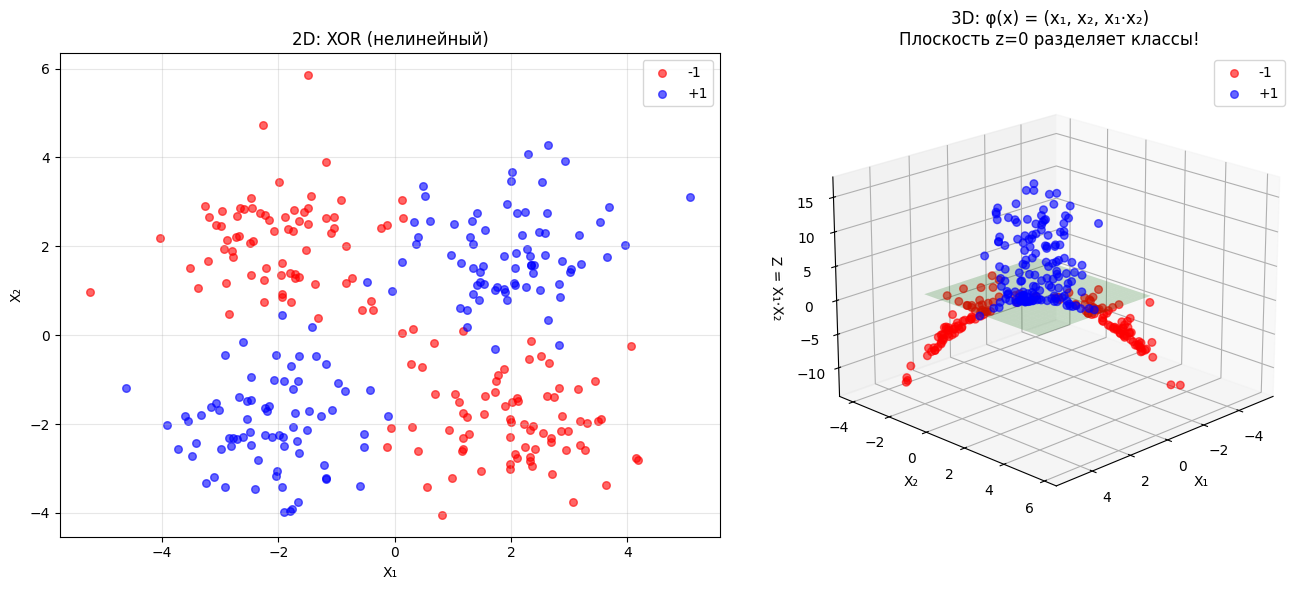

In [15]:
# ============================================
# Генерация XOR-паттерна
# ============================================

np.random.seed(42)
n_xor = 300 // 4

X_xor_1 = np.random.randn(n_xor, 2) + np.array([-2, -2])  # левый-нижний → +1
X_xor_2 = np.random.randn(n_xor, 2) + np.array([-2, 2])   # левый-верхний → -1
X_xor_3 = np.random.randn(n_xor, 2) + np.array([2, -2])   # правый-нижний → -1
X_xor_4 = np.random.randn(n_xor, 2) + np.array([2, 2])    # правый-верхний → +1

X_xor = np.vstack([X_xor_1, X_xor_2, X_xor_3, X_xor_4])
y_xor = np.hstack([
    np.ones(n_xor),    # +1
    -np.ones(n_xor),   # -1
    -np.ones(n_xor),   # -1
    np.ones(n_xor)     # +1
])

# ============================================
# Преобразование XOR в 3D: φ(x) = (x₁, x₂, x₁·x₂)
# ============================================

X_xor_3d = np.column_stack([
    X_xor[:, 0],
    X_xor[:, 1],
    X_xor[:, 0] * X_xor[:, 1]  # z = x₁·x₂
])

# ============================================
# Визуализация XOR
# ============================================

fig = plt.figure(figsize=(14, 6))

# 2D
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(
    X_xor[y_xor == -1, 0],
    X_xor[y_xor == -1, 1],
    color='red', label='-1', s=30, alpha=0.6
)
ax1.scatter(
    X_xor[y_xor == 1, 0],
    X_xor[y_xor == 1, 1],
    color='blue', label='+1', s=30, alpha=0.6
)
ax1.set_title('2D: XOR (нелинейный)', fontsize=12)
ax1.set_xlabel('X₁')
ax1.set_ylabel('X₂')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(
    X_xor_3d[y_xor == -1, 0],
    X_xor_3d[y_xor == -1, 1],
    X_xor_3d[y_xor == -1, 2],
    color='red', label='-1', s=30, alpha=0.6
)
ax2.scatter(
    X_xor_3d[y_xor == 1, 0],
    X_xor_3d[y_xor == 1, 1],
    X_xor_3d[y_xor == 1, 2],
    color='blue', label='+1', s=30, alpha=0.6
)

# Рисуем разделяющую плоскость z = 0
x_range = np.linspace(-3, 3, 20)
y_range = np.linspace(-3, 3, 20)
X_plane, Y_plane = np.meshgrid(x_range, y_range)
Z_plane = np.zeros_like(X_plane)
ax2.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.2, color='green', edgecolor='none')

ax2.set_title('3D: φ(x) = (x₁, x₂, x₁·x₂)\nПлоскость z=0 разделяет классы!', fontsize=12)
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Z = X₁·X₂')
ax2.view_init(elev=20, azim=45)
ax2.legend()

plt.tight_layout()
plt.show()

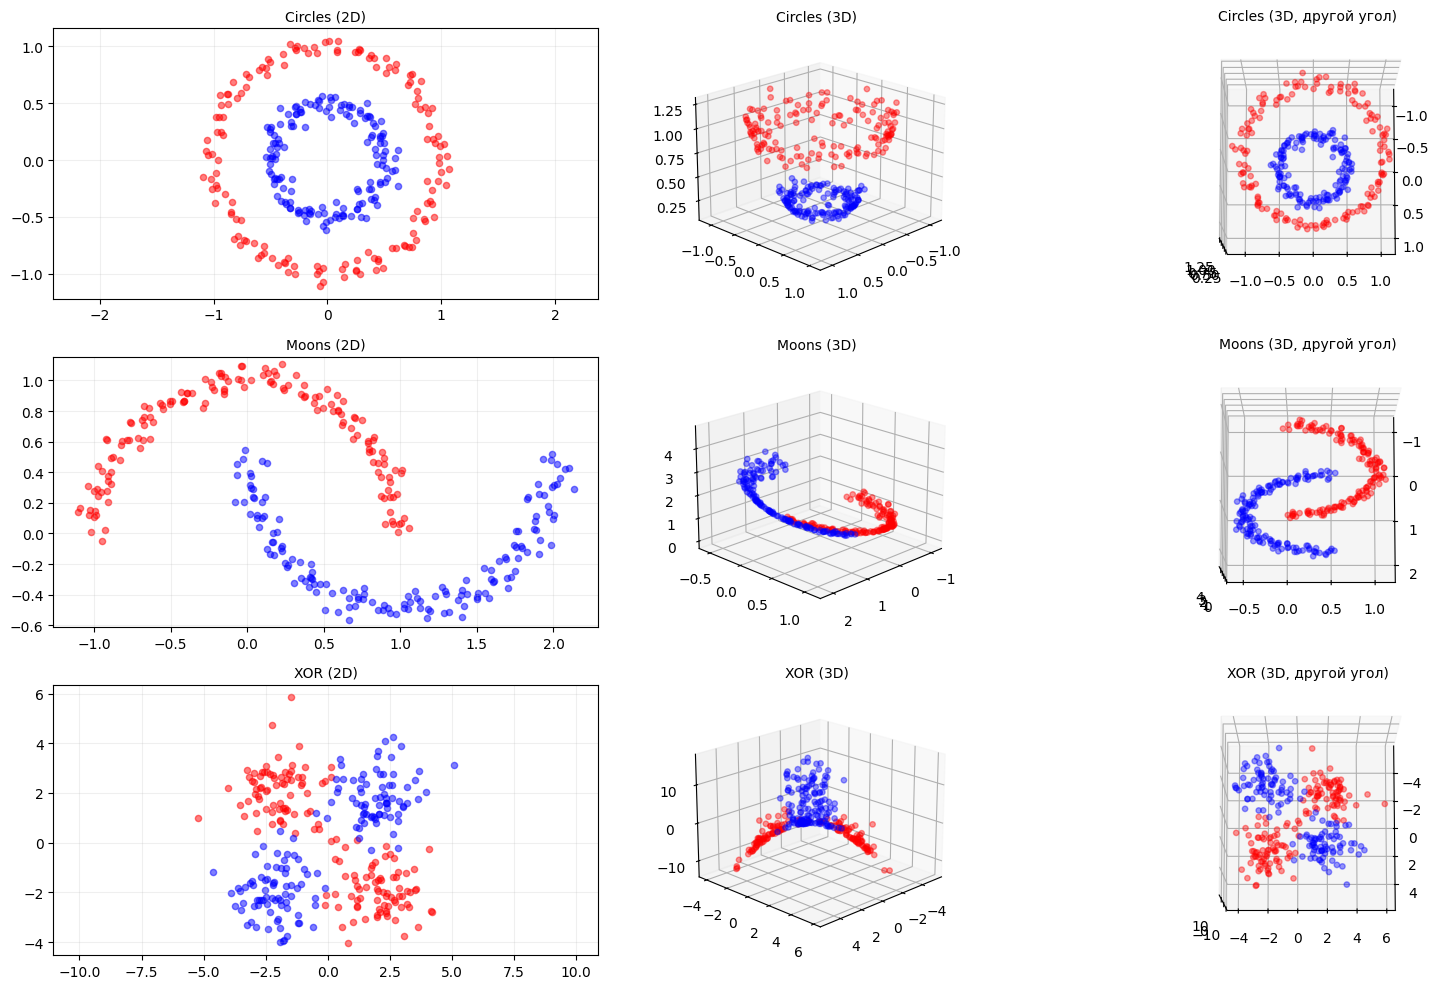

In [16]:
# ============================================
# Сводная визуализация: 2D и 3D для всех паттернов
# ============================================

fig = plt.figure(figsize=(16, 10))

# Определяем все датасеты и их преобразования
datasets_3d = [
    (X_circles, y_circles, 'Circles', lambda x: np.column_stack([x[:,0], x[:,1], x[:,0]**2 + x[:,1]**2])),
    (X_moons, y_moons, 'Moons', lambda x: np.column_stack([x[:,0], x[:,1], x[:,0]**2 + x[:,1]**2])),
    (X_xor, y_xor, 'XOR', lambda x: np.column_stack([x[:,0], x[:,1], x[:,0]*x[:,1]]))
]

for idx, (X, y, name, transform) in enumerate(datasets_3d, 1):
    X_3d = transform(X)
    
    # 2D
    ax1 = fig.add_subplot(3, 3, (idx-1)*3 + 1)
    ax1.scatter(X[y == -1, 0], X[y == -1, 1], color='red', s=20, alpha=0.5)
    ax1.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', s=20, alpha=0.5)
    ax1.set_title(f'{name} (2D)', fontsize=10)
    ax1.axis('equal')
    ax1.grid(True, alpha=0.2)
    
    # 3D
    ax2 = fig.add_subplot(3, 3, (idx-1)*3 + 2, projection='3d')
    ax2.scatter(X_3d[y == -1, 0], X_3d[y == -1, 1], X_3d[y == -1, 2], 
                color='red', s=15, alpha=0.4)
    ax2.scatter(X_3d[y == 1, 0], X_3d[y == 1, 1], X_3d[y == 1, 2], 
                color='blue', s=15, alpha=0.4)
    ax2.set_title(f'{name} (3D)', fontsize=10)
    ax2.view_init(elev=20, azim=45)
    
    # 3D с другой стороны
    ax3 = fig.add_subplot(3, 3, (idx-1)*3 + 3, projection='3d')
    ax3.scatter(X_3d[y == -1, 0], X_3d[y == -1, 1], X_3d[y == -1, 2], 
                color='red', s=15, alpha=0.4)
    ax3.scatter(X_3d[y == 1, 0], X_3d[y == 1, 1], X_3d[y == 1, 2], 
                color='blue', s=15, alpha=0.4)
    ax3.set_title(f'{name} (3D, другой угол)', fontsize=10)
    ax3.view_init(elev=80, azim=0)

plt.tight_layout()
plt.show()

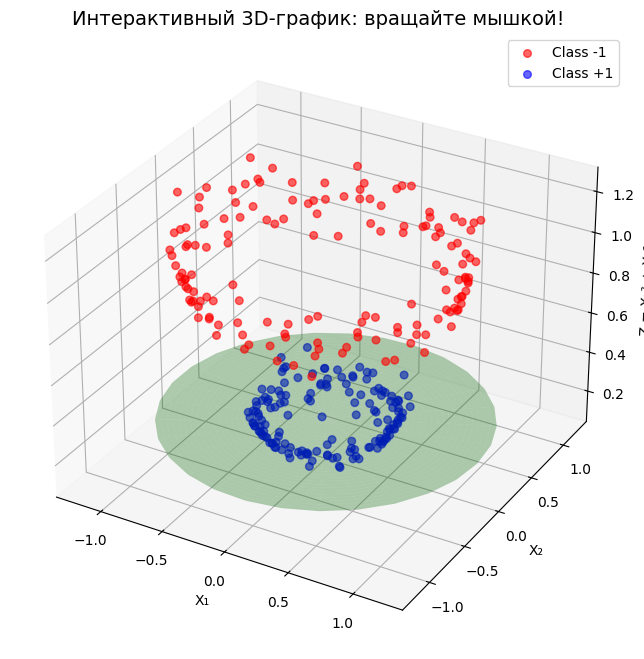

In [17]:
# ============================================
# Интерактивный 3D-график (вращается мышкой)
# ============================================

# Для Jupyter: раскомментируйте следующую строку
# %matplotlib notebook

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_circles_3d[y_circles == -1, 0],
    X_circles_3d[y_circles == -1, 1],
    X_circles_3d[y_circles == -1, 2],
    color='red', label='Class -1', s=30, alpha=0.6
)
ax.scatter(
    X_circles_3d[y_circles == 1, 0],
    X_circles_3d[y_circles == 1, 1],
    X_circles_3d[y_circles == 1, 2],
    color='blue', label='Class +1', s=30, alpha=0.6
)

# Плоскость z = R²
R = 0.5
theta_plane = np.linspace(0, 2*np.pi, 30)
r_plane = np.linspace(0, 1.2, 30)
R_grid, Theta_grid = np.meshgrid(r_plane, theta_plane)
X_plane = R_grid * np.cos(Theta_grid)
Y_plane = R_grid * np.sin(Theta_grid)
Z_plane = R**2 * np.ones_like(X_plane)
ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.3, color='green', edgecolor='none')

ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
ax.set_zlabel('Z = X₁² + X₂²')
ax.set_title('Интерактивный 3D-график: вращайте мышкой!', fontsize=14)
ax.legend()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Уравнение плоскости SVM: -0.07·x₁ + 0.16·x₂ + -5.45·z + 3.44 = 0
Вес для координаты z = x₁² + x₂²: -5.45


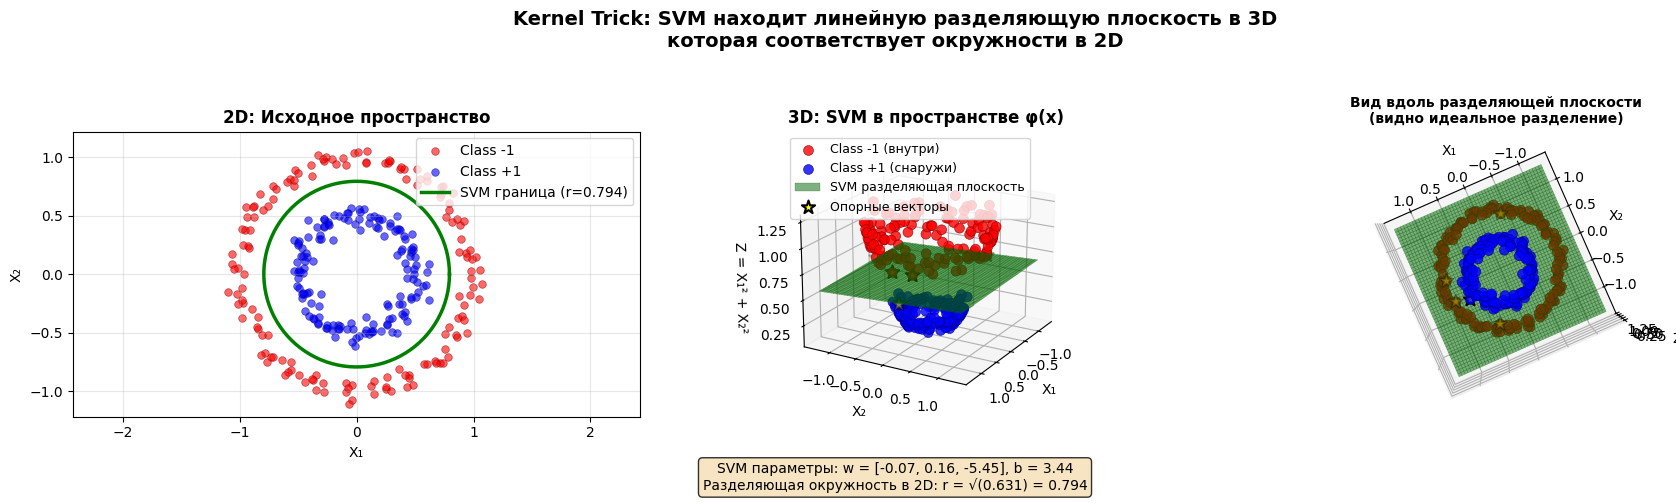


ИНФОРМАЦИЯ О SVM-РАЗДЕЛЕНИИ:
Количество опорных векторов: 5
Уравнение плоскости: -0.07x₁ + 0.16x₂ + -5.45(x₁²+x₂²) + 3.44 = 0
Разделяющая окружность в 2D: x₁² + x₂² = 0.631
Радиус окружности: R = 0.794


In [18]:
# ============================================
# Преобразование в 3D: φ(x) = (x₁, x₂, x₁² + x₂²)
# с SVM-подобной разделяющей плоскостью
# ============================================

from mpl_toolkits.mplot3d import Axes3D
from sklearn import svm

# Добавляем третью координату: квадрат расстояния от центра
X_circles_3d = np.column_stack([
    X_circles[:, 0],                        # x₁
    X_circles[:, 1],                        # x₂
    X_circles[:, 0]**2 + X_circles[:, 1]**2 # z = x₁² + x₂²
])

# Обучаем SVM в 3D пространстве
svm_3d = svm.SVC(kernel='linear', C=1000)
svm_3d.fit(X_circles_3d, y_circles)

# Получаем параметры разделяющей гиперплоскости
w = svm_3d.coef_[0]  # вектор нормали
b = svm_3d.intercept_[0]  # смещение

print(f"Уравнение плоскости SVM: {w[0]:.2f}·x₁ + {w[1]:.2f}·x₂ + {w[2]:.2f}·z + {b:.2f} = 0")
print(f"Вес для координаты z = x₁² + x₂²: {w[2]:.2f}")

# ============================================
# УЛУЧШЕННАЯ ВИЗУАЛИЗАЦИЯ С SVM-ПЛОСКОСТЬЮ
# ============================================

fig = plt.figure(figsize=(18, 5))

# --- 2D проекция с окружностью ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(
    X_circles[y_circles == -1, 0],
    X_circles[y_circles == -1, 1],
    color='red', label='Class -1', s=30, alpha=0.6, edgecolors='darkred', linewidth=0.5
)
ax1.scatter(
    X_circles[y_circles == 1, 0],
    X_circles[y_circles == 1, 1],
    color='blue', label='Class +1', s=30, alpha=0.6, edgecolors='darkblue', linewidth=0.5
)
# Оптимальная разделяющая окружность в 2D
R_optimal = np.sqrt(-b / w[2])  # из уравнения плоскости при z = x²+y²
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(R_optimal*np.cos(theta), R_optimal*np.sin(theta), 
         'green', linewidth=2.5, linestyle='-', label=f'SVM граница (r={R_optimal:.3f})')
ax1.set_title('2D: Исходное пространство', fontsize=12, fontweight='bold')
ax1.set_xlabel('X₁')
ax1.set_ylabel('X₂')
ax1.legend(loc='upper right')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)

# --- 3D вид с SVM-плоскостью (оптимальный ракурс) ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

# Точки класса -1 (внутренние)
ax2.scatter(
    X_circles_3d[y_circles == -1, 0],
    X_circles_3d[y_circles == -1, 1],
    X_circles_3d[y_circles == -1, 2],
    color='red', s=50, alpha=0.8, edgecolors='darkred', 
    linewidth=0.5, label='Class -1 (внутри)'
)

# Точки класса +1 (внешние)
ax2.scatter(
    X_circles_3d[y_circles == 1, 0],
    X_circles_3d[y_circles == 1, 1],
    X_circles_3d[y_circles == 1, 2],
    color='blue', s=50, alpha=0.8, edgecolors='darkblue', 
    linewidth=0.5, label='Class +1 (снаружи)'
)

# Создаем сетку для SVM-плоскости
xx, yy = np.meshgrid(np.linspace(-1.3, 1.3, 50),
                      np.linspace(-1.3, 1.3, 50))

# Вычисляем z из уравнения плоскости: w[0]*x + w[1]*y + w[2]*z + b = 0
zz = (-w[0] * xx - w[1] * yy - b) / w[2]

# Рисуем SVM разделяющую плоскость
ax2.plot_surface(xx, yy, zz, alpha=0.5, color='green', 
                 edgecolor='darkgreen', linewidth=0.3, 
                 label='SVM разделяющая плоскость')

# Добавляем опорные векторы (если есть)
support_vectors = svm_3d.support_vectors_
if len(support_vectors) > 0:
    ax2.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        support_vectors[:, 2],
        color='yellow', s=100, marker='*', 
        edgecolors='black', linewidth=1.5,
        label='Опорные векторы', zorder=5
    )

ax2.set_title('3D: SVM в пространстве φ(x)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Z = X₁² + X₂²')
ax2.view_init(elev=20, azim=30)
ax2.legend(loc='upper left', fontsize=9)

# --- 3D вид, показывающий разделение (вид вдоль плоскости) ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Точки
ax3.scatter(
    X_circles_3d[y_circles == -1, 0],
    X_circles_3d[y_circles == -1, 1],
    X_circles_3d[y_circles == -1, 2],
    color='red', s=50, alpha=0.8, edgecolors='darkred', linewidth=0.5
)
ax3.scatter(
    X_circles_3d[y_circles == 1, 0],
    X_circles_3d[y_circles == 1, 1],
    X_circles_3d[y_circles == 1, 2],
    color='blue', s=50, alpha=0.8, edgecolors='darkblue', linewidth=0.5
)

# SVM плоскость
ax3.plot_surface(xx, yy, zz, alpha=0.5, color='green', 
                 edgecolor='darkgreen', linewidth=0.3)

# Опорные векторы
if len(support_vectors) > 0:
    ax3.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        support_vectors[:, 2],
        color='yellow', s=100, marker='*', 
        edgecolors='black', linewidth=1.5, zorder=5
    )

# Устанавливаем вид вдоль разделяющей плоскости
# Нормаль к плоскости: w = (w[0], w[1], w[2])
# Вычисляем углы обзора, чтобы смотреть вдоль плоскости
azim_angle = np.arctan2(w[1], w[0]) * 180 / np.pi
elev_angle = 90 - np.arccos(w[2] / np.linalg.norm(w)) * 180 / np.pi

ax3.view_init(elev=elev_angle, azim=azim_angle)
ax3.set_title('Вид вдоль разделяющей плоскости\n(видно идеальное разделение)', 
              fontsize=10, fontweight='bold')
ax3.set_xlabel('X₁')
ax3.set_ylabel('X₂')
ax3.set_zlabel('Z')

# Добавляем информацию о параметрах SVM
plt.figtext(0.5, 0.02, 
            f'SVM параметры: w = [{w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f}], b = {b:.2f}\n'
            f'Разделяющая окружность в 2D: r = √({-b/w[2]:.3f}) = {R_optimal:.3f}',
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Kernel Trick: SVM находит линейную разделяющую плоскость в 3D\n'
             'которая соответствует окружности в 2D', 
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# Выводим дополнительную информацию
print("\n" + "="*60)
print("ИНФОРМАЦИЯ О SVM-РАЗДЕЛЕНИИ:")
print("="*60)
print(f"Количество опорных векторов: {len(support_vectors)}")
print(f"Уравнение плоскости: {w[0]:.2f}x₁ + {w[1]:.2f}x₂ + {w[2]:.2f}(x₁²+x₂²) + {b:.2f} = 0")
print(f"Разделяющая окружность в 2D: x₁² + x₂² = {R_optimal**2:.3f}")
print(f"Радиус окружности: R = {R_optimal:.3f}")
print("="*60)

## 🎯 2. Генерация данных для линейного SVM

### Теория

Для демонстрации работы **линейного SVM** (Primal, градиентный спуск) нам нужны два класса, которые **можно разделить прямой линией**. Это означает, что облака точек не должны пересекаться — между ними должен быть "коридор" (зазор).

Мы сгенерируем два класса:
- **Класс -1**: центр в (-3, 0), круглая форма
- **Класс +1**: центр в (3, 0), круглая форма

Расстояние между центрами — 6 единиц, радиус каждого облака (стандартное отклонение) — 1.5 единицы. Это даёт хороший зазор между классами.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons

# Параметры генерации
np.random.seed(42)
n_samples = 200

# ============================================
# 1. Линейно разделимые данные (для Primal SVM)
# ============================================

# Генерируем два облака с разными центрами
X_linear, y_linear = make_blobs(
    n_samples=n_samples,
    centers=[[-3, 0], [3, 0]],
    cluster_std=1.5,
    n_features=2,
    random_state=42
)

# Преобразуем метки в -1/+1 (нужно для SVM)
y_linear = np.where(y_linear == 0, -1, 1)

print(f"X_linear shape: {X_linear.shape}")
print(f"y_linear shape: {y_linear.shape}")
print(f"Уникальные метки: {np.unique(y_linear)}")

X_linear shape: (200, 2)
y_linear shape: (200,)
Уникальные метки: [-1  1]


## 📊 3. Визуализация данных

### Теория

Для визуализации двумерных данных мы используем **точечный график (scatter plot)**:
- Ось X — первый признак
- Ось Y — второй признак
- Цвет точки — её класс

Это позволяет нам "увидеть" данные глазами и оценить:
- Насколько классы разделимы
- Есть ли выбросы
- Какую форму имеют облака

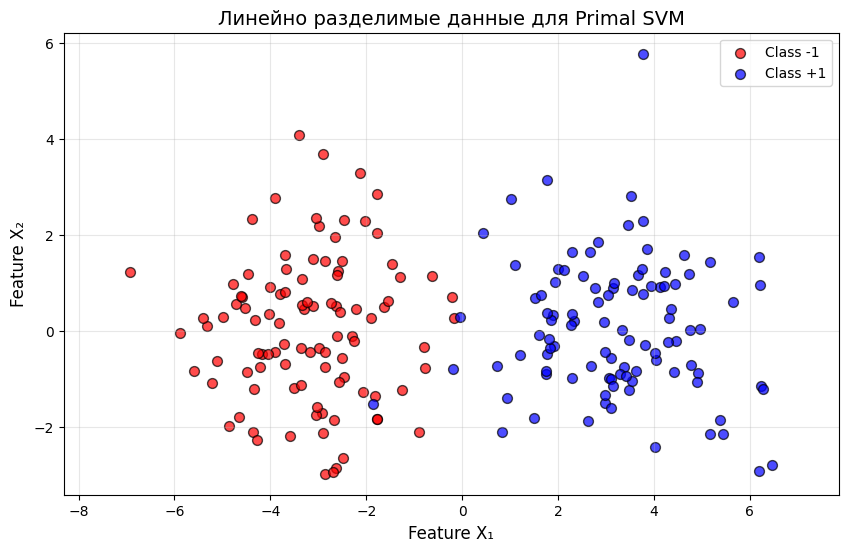

In [20]:
# ============================================
# Визуализация линейно разделимых данных
# ============================================

plt.figure(figsize=(10, 6))
plt.scatter(
    X_linear[y_linear == -1, 0],
    X_linear[y_linear == -1, 1],
    color='red',
    label='Class -1',
    s=50,
    alpha=0.7,
    edgecolors='k'
)
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    color='blue',
    label='Class +1',
    s=50,
    alpha=0.7,
    edgecolors='k'
)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Линейно разделимые данные для Primal SVM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 📐 4. Разделяющая линия и Margin — геометрия SVM

### Уравнение гиперплоскости

В двумерном случае разделяющая линия (гиперплоскость) задаётся уравнением:

**w₁·x₁ + w₂·x₂ + b = 0**

где:
- **w = (w₁, w₂)** — вектор весов (нормаль к линии, перпендикулярен ей)
- **b** — смещение (bias)

### Почему w — это нормаль?

Возьмём две точки x₁ и x₂, лежащие на линии:
- w·x₁ + b = 0
- w·x₂ + b = 0

Вычтем: w·(x₁ − x₂) = 0

Вектор (x₁ − x₂) лежит **внутри** линии (соединяет две её точки). Его скалярное произведение с w равно нулю → значит **w перпендикулярен линии**.

### Расстояние от точки до линии

Для точки x₀ расстояние до линии вычисляется по формуле:

**d = |w·x₀ + b| / ||w||**

где ||w|| = √(w₁² + w₂²) — длина (норма) вектора w.

### Границы полосы (Margin)

SVM стремится максимизировать ширину "улицы" между классами. Границы этой улицы задаются двумя параллельными линиями:

- **w·x + b = +1** — ближайшие точки класса +1
- **w·x + b = -1** — ближайшие точки класса -1

### Ширина полосы (Margin)

Расстояние между этими двумя параллельными линиями:

**margin = 2 / ||w||**

**Доказательство (ключевой момент):**

Возьмём точки x⁺ на линии +1 и x⁻ на линии -1, и выберем их так, чтобы вектор (x⁺ − x⁻) был **параллелен нормали w** (кратчайший путь между линиями).

Запишем разность уравнений:
- (w·x⁺ + b) − (w·x⁻ + b) = 1 − (−1) = 2
- w·(x⁺ − x⁻) = 2

Так как x⁺ − x⁻ параллелен w, его можно записать как t · (w/||w||), где t — это искомая длина (расстояние между линиями).

Подставляем:
- w · (t · w/||w||) = 2
- t · ||w|| = 2
- **t = 2 / ||w||** ← это и есть margin!

### Что мы минимизируем?

Наша цель — **максимизировать margin = 2/||w||**.

Дробь тем больше, чем **меньше знаменатель ||w||**. Поэтому максимизация margin эквивалентна **минимизации ||w||²/2** (квадрат для гладкости, 1/2 для удобства дифференцирования).

### Оптимизационная задача (Primal)

**Минимизировать:** (1/2)·||w||²

**При условии:** yᵢ·(w·xᵢ + b) ≥ 1 для всех точек i

где yᵢ = +1 или -1 (метка класса).

Это и есть **примальная задача SVM** — мы будем решать её через градиентный спуск в Главе 2.

## 🎯 5. Визуализация разделяющей линии и Margin

### Теория

После обучения Primal SVM (Глава 2) мы получим w и b. Тогда мы сможем нарисовать:

1. **Разделяющую линию:** w·x + b = 0
2. **Верхнюю границу margin:** w·x + b = +1
3. **Нижнюю границу margin:** w·x + b = -1
4. **Опорные векторы** — точки, которые лежат ровно на границах margin

Здесь мы покажем **как это будет выглядеть**, используя предварительно обученную модель (в Главе 2 мы обучим её сами).

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


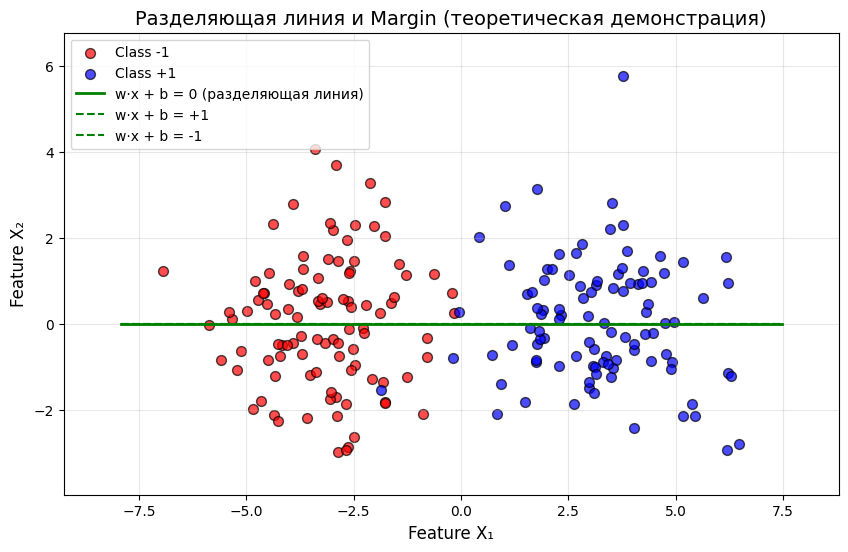

In [21]:
# ============================================
# Демонстрация разделяющей линии и margin
# ============================================

# Для демонстрации мы используем заранее известные w и b
# (в Главе 2 мы научимся их находить через градиентный спуск)

# Примерные значения w и b (полученные после обучения)
w_demo = np.array([0.8, 0.0])
b_demo = 0.0

# Создаём сетку для отрисовки линии
x_min, x_max = X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1
y_min, y_max = X_linear[:, 1].min() - 1, X_linear[:, 1].max() + 1

# Линия уровня для w·x + b = 0
xx = np.linspace(x_min, x_max, 100)
yy_sep = -(w_demo[0] * xx + b_demo) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)

# Линии уровня для w·x + b = ±1 (границы margin)
yy_plus = -(w_demo[0] * xx + b_demo - 1) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)
yy_minus = -(w_demo[0] * xx + b_demo + 1) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)

# Рисуем
plt.figure(figsize=(10, 6))

# Точки
plt.scatter(
    X_linear[y_linear == -1, 0],
    X_linear[y_linear == -1, 1],
    color='red', label='Class -1', s=50, alpha=0.7, edgecolors='k'
)
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    color='blue', label='Class +1', s=50, alpha=0.7, edgecolors='k'
)

# Разделяющая линия
plt.plot(xx, yy_sep, 'g-', linewidth=2, label='w·x + b = 0 (разделяющая линия)')

# Границы margin
plt.plot(xx, yy_plus, 'g--', linewidth=1.5, label='w·x + b = +1')
plt.plot(xx, yy_minus, 'g--', linewidth=1.5, label='w·x + b = -1')

# Заливка полосы (margin)
plt.fill_between(xx, yy_minus, yy_plus, color='green', alpha=0.1)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Разделяющая линия и Margin (теоретическая демонстрация)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

## 🧠 6. Генерация нелинейных данных для тестирования ядер

### Теория

Для тестирования ядер (RBF, Polynomial) нам нужны данные, которые **нельзя разделить прямой линией**. Мы сгенерируем три классических паттерна:

1. **Концентрические окружности (Circles)** — один класс внутри круга, другой — снаружи. Прямая линия не справится, нужна круговая граница (RBF-ядро).
2. **Два полумесяца (Moons)** — два изогнутых кластера. Классический тест для нелинейных классификаторов.
3. **XOR-паттерн** — четыре кластера по углам, классы расположены по диагонали.

Все эти паттерны встроены в sklearn и генерируются одной строкой.

In [22]:
# ============================================
# 2. Концентрические окружности (для RBF-ядра)
# ============================================

X_circles, y_circles = make_circles(
    n_samples=n_samples,
    factor=0.5,
    noise=0.05,
    random_state=42
)
y_circles = np.where(y_circles == 0, -1, 1)

# ============================================
# 3. Два полумесяца (Moons)
# ============================================

X_moons, y_moons = make_moons(
    n_samples=n_samples,
    noise=0.05,
    random_state=42
)
y_moons = np.where(y_moons == 0, -1, 1)

# ============================================
# 4. XOR-паттерн (вручную)
# ============================================

np.random.seed(42)
n_xor = n_samples // 4

# Четыре кластера по углам
X_xor_1 = np.random.randn(n_xor, 2) + np.array([-2, -2])
X_xor_2 = np.random.randn(n_xor, 2) + np.array([-2, 2])
X_xor_3 = np.random.randn(n_xor, 2) + np.array([2, -2])
X_xor_4 = np.random.randn(n_xor, 2) + np.array([2, 2])

X_xor = np.vstack([X_xor_1, X_xor_2, X_xor_3, X_xor_4])

# Метки по диагонали: класс -1 для левого-верхнего и правого-нижнего
y_xor = np.hstack([
    np.ones(n_xor),      # левый-нижний → +1
    -np.ones(n_xor),     # левый-верхний → -1
    -np.ones(n_xor),     # правый-нижний → -1
    np.ones(n_xor)       # правый-верхний → +1
])

print(f"X_circles shape: {X_circles.shape}")
print(f"X_moons shape: {X_moons.shape}")
print(f"X_xor shape: {X_xor.shape}")

X_circles shape: (200, 2)
X_moons shape: (200, 2)
X_xor shape: (200, 2)


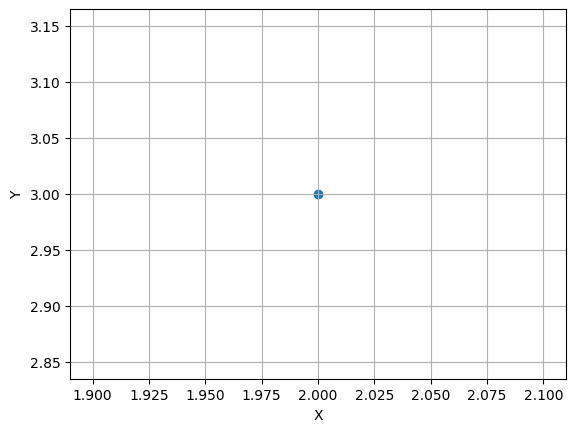

In [23]:
import numpy as np
import matplotlib.pyplot as plt

mean_minus1 = np.array([2.0, 3.0])

plt.scatter(mean_minus1[0], mean_minus1[1])
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()